# Práctica Tasación vivienda
#### Modelos a usar:
- Gradiente Boosting Regressor
- Regresión Lineal Múltiple

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Componentes de Scikit-Learn para la validación y métricas
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

In [195]:
## Cargamos los datos

data = pd.read_excel(r"Datos_Tasacion_Viviendas_Gradient_Boosting_regressor.xlsx")

data.head()

,ID_Inmueble,Metros_Cuadrados,Habitaciones,Latitud,Longitud,Ano_Construccion,Servicios_Cercanos,Precio_Comercial_EUR
0,PROP-1001,208,4,40.38250,-3.72250,1988,6,917281
1,PROP-1002,218,6,40.46922,-3.74131,2014,3,680132
2,PROP-1003,100,2,40.43054,-3.74735,1985,15,427996
3,PROP-1004,195,5,40.46094,-3.74935,1980,15,619561
4,PROP-1005,84,2,40.47572,-3.71634,1971,14,284220


In [196]:
display(data)

,ID_Inmueble,Metros_Cuadrados,Habitaciones,Latitud,Longitud,Ano_Construccion,Servicios_Cercanos,Precio_Comercial_EUR
0,PROP-1001,208,4,40.38250,-3.72250,1988,6,917281
1,PROP-1002,218,6,40.46922,-3.74131,2014,3,680132
2,PROP-1003,100,2,40.43054,-3.74735,1985,15,427996
3,PROP-1004,195,5,40.46094,-3.74935,1980,15,619561
4,PROP-1005,84,2,40.47572,-3.71634,1971,14,284220
...,...,...,...,...,...,...,...,...
95,PROP-1096,149,4,40.43552,-3.72597,2020,17,907652
96,PROP-1097,49,1,40.38931,-3.72784,1991,11,289123
97,PROP-1098,139,4,40.43535,-3.71562,2002,13,869807
98,PROP-1099,114,4,40.40514,-3.73793,1984,12,538841


In [197]:
data.describe()

,Metros_Cuadrados,Habitaciones,Latitud,Longitud,Ano_Construccion,Servicios_Cercanos,Precio_Comercial_EUR
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,155.120000,3.720000,40.430215,-3.699083,1992.460000,9.980000,6.874621e+05
std,60.473933,1.333939,0.030288,0.030426,17.690618,4.442631,2.647029e+05
min,49.000000,1.000000,40.380720,-3.749350,1960.000000,2.000000,2.123410e+05
25%,105.250000,3.000000,40.403613,-3.726195,1979.000000,6.000000,5.061558e+05
50%,150.500000,4.000000,40.432870,-3.699650,1991.000000,10.000000,6.667575e+05
75%,214.250000,4.000000,40.455013,-3.672898,2005.750000,14.000000,8.948835e+05
max,250.000000,6.000000,40.477380,-3.651210,2025.000000,18.000000,1.333050e+06


In [198]:
# Revisar si existen valores nulos

data.isnull().sum()

ID_Inmueble             0
Metros_Cuadrados        0
Habitaciones            0
Latitud                 0
Longitud                0
Ano_Construccion        0
Servicios_Cercanos      0
Precio_Comercial_EUR    0
dtype: int64

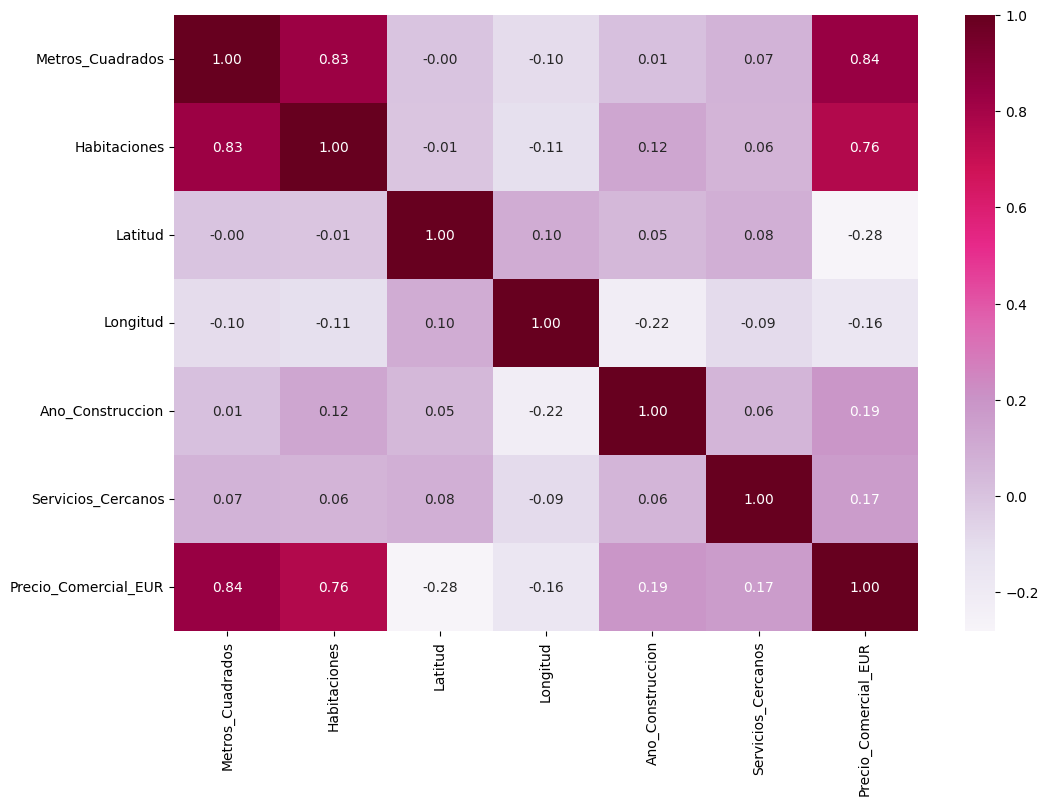

In [199]:
# Revisamos que correlación existe entre las variables

data.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap="PuRd",
            fmt=".2f")

plt.show()

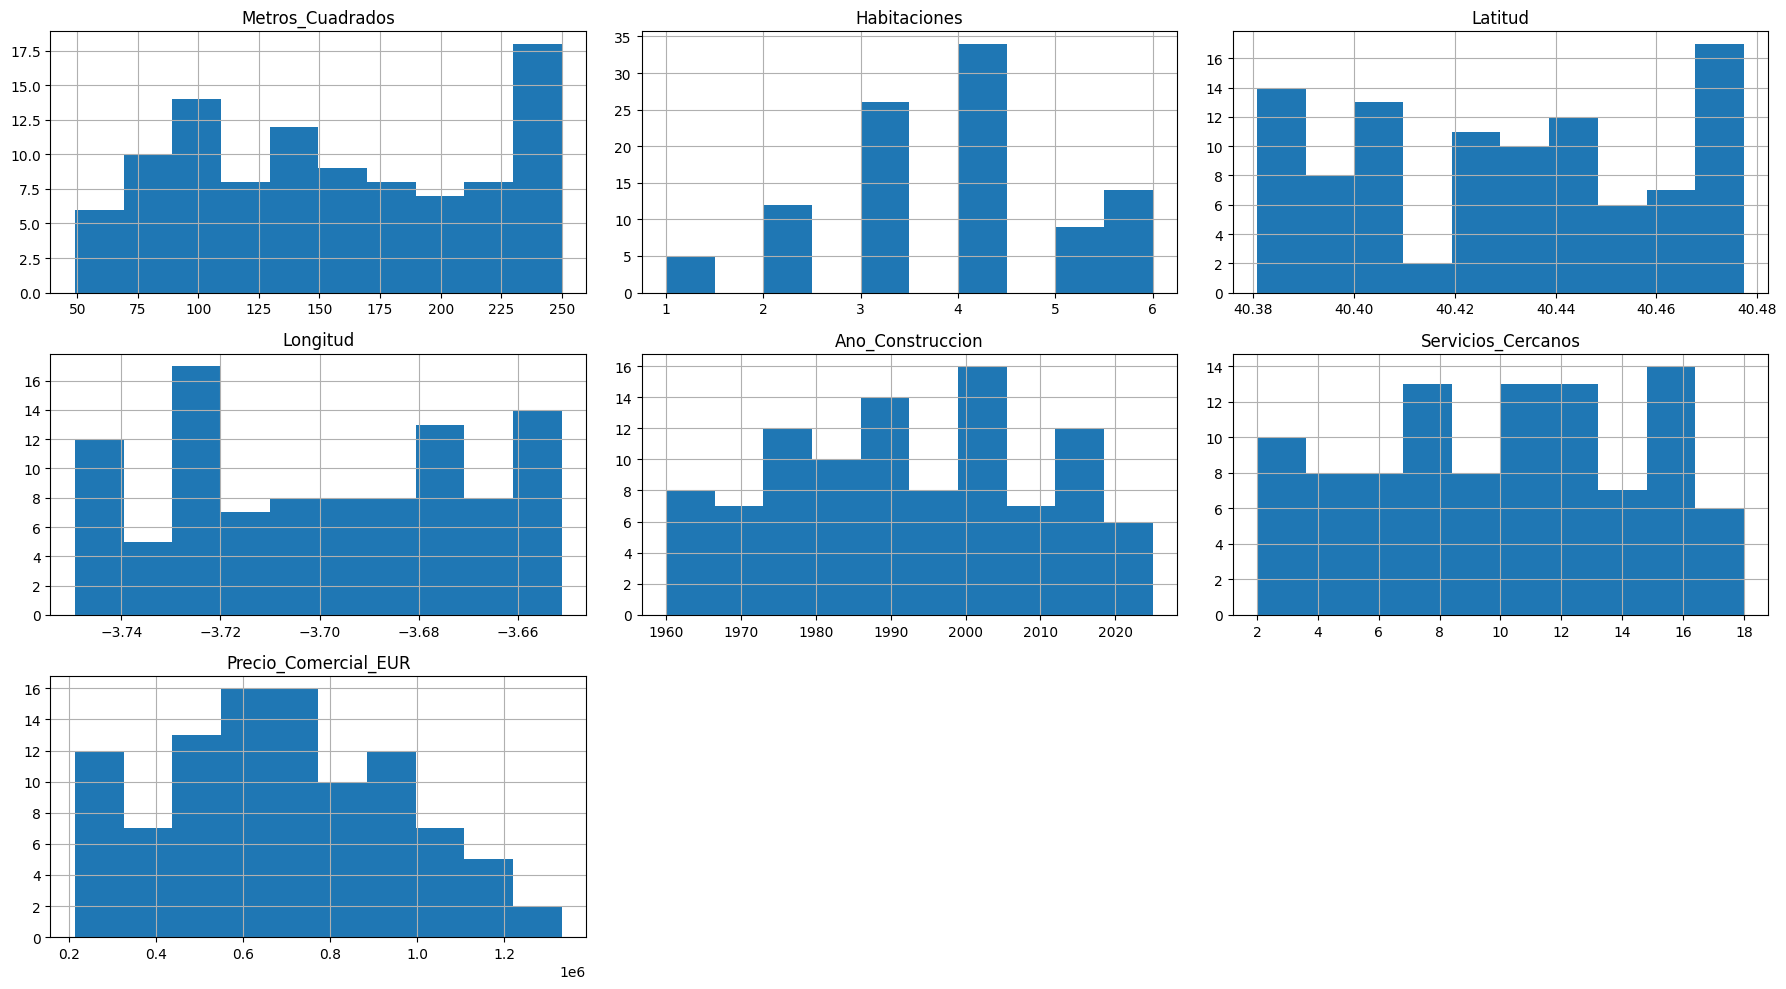

In [200]:
# Distribución de las variables

data.hist(figsize=(18, 10))

plt.tight_layout()
plt.show()

In [201]:
data.head()

,ID_Inmueble,Metros_Cuadrados,Habitaciones,Latitud,Longitud,Ano_Construccion,Servicios_Cercanos,Precio_Comercial_EUR
0,PROP-1001,208,4,40.38250,-3.72250,1988,6,917281
1,PROP-1002,218,6,40.46922,-3.74131,2014,3,680132
2,PROP-1003,100,2,40.43054,-3.74735,1985,15,427996
3,PROP-1004,195,5,40.46094,-3.74935,1980,15,619561
4,PROP-1005,84,2,40.47572,-3.71634,1971,14,284220


In [202]:
# Asignación de datos y definicion de train-test

X = data[["Metros_Cuadrados", "Habitaciones", "Latitud", "Longitud", "Ano_Construccion","Servicios_Cercanos" ]]
y = data["Precio_Comercial_EUR"]

X_train, x_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.20, 
                                                    random_state=42,
                                                    )

- No estratificado --> variable continua (Precio)

In [203]:
# Construir el modelo

modelo_estimacion = GradientBoostingRegressor(
    n_estimators= 200,
    learning_rate= 0.1,
    max_depth=2,
    random_state=42
)

modelo_estimacion.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


- Reduje la profundidad a 2 para que cada árbol individual fuera muy simple
- Compensé esa simplicidad con más árboles (200), lo que dio 
- Modelo más robusto y que generaliza mejor a viviendas nuevas.

In [204]:
# Generar predicciones

y_pred = modelo_estimacion.predict(x_test)

In [205]:
# Cálculo de metricas y validación

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

In [206]:
print("--- RESULTADOS DE LA MODELIZACION  ---") 
print(f"1. Error Absoluto Medio (MAE): {mae:.2f} €") 
print(f"2. Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} €") 
print(f"3. Precisión del Modelo (R² Score): {r2:.4f} ({r2*100:.1f}% de varianza explicada)") 
print(f"MAPE: {mape:.2f}%")

--- RESULTADOS DE LA MODELIZACION  ---
1. Error Absoluto Medio (MAE): 72738.46 €
2. Raíz del Error Cuadrático Medio (RMSE): 91273.85 €
3. Precisión del Modelo (R² Score): 0.8804 (88.0% de varianza explicada)
MAPE: 10.92%



--- RESULTADOS SOBRE TEST (modelo normalizado) ---
MAE: 84,971.74 €
RMSE: 102,925.05 €
R² (test): 0.8480
MAPE: 13.37%

### MODELO CON 2 RAMAS Y 200 ESTIMACIONES

- MAE: el modelo se equivocara en 72738.46 € € arriba/abajo
- RMSE: 91273.85 € hay viviendas donde el modelo falla bastante
- R² Score:con las variables que hemos pusto el modelo acierta un 88.0% 
- MAPE = 10.92% --> el modelo se esta equivocando un 10.92% sobre el precio real de cada vivienda. 

### MODELO CON 3 RAMAS Y 100 ESTIMACIONES

- MAE: el modelo se equivocara en 84198.13 € arriba/abajo
- RMSE: 107111.76 € € hay viviendas donde el modelo falla bastante
- R² Score:con las variables que hemos pusto el modelo acierta un 83.5%
- MAPE = 12.69 % --> el modelo se esta equivocando un 12.69 % sobre el precio real de cada vivienda. 

### MODELO CON 4 RAMAS Y 60 ESTIMACIONES

- MAE: el modelo se equivocara en 85270.15 € arriba/abajo
- RMSE: 110110.36 € hay viviendas donde el modelo falla bastante
- R² Score:con las variables que hemos pusto el modelo acierta un 82.6%
- MAPE = 12.85% --> el modelo se esta equivocando un 12.85% sobre el precio real de cada vivienda. 

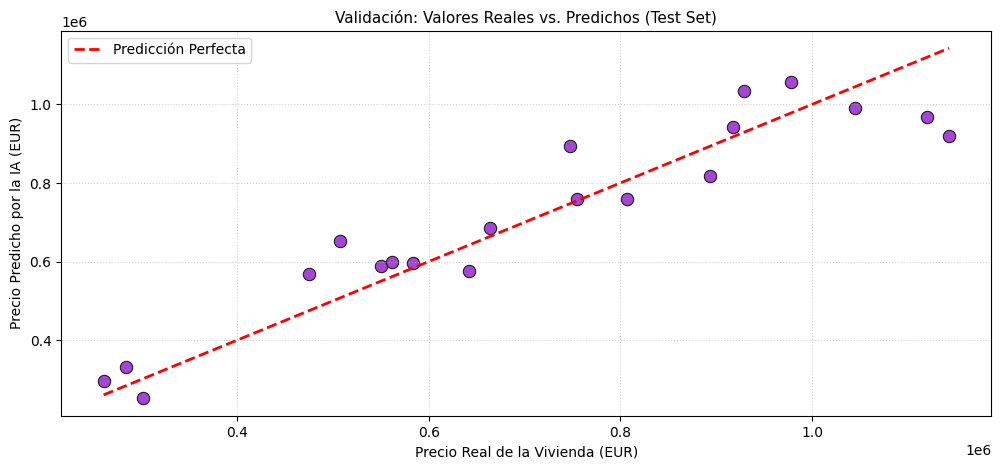

In [207]:
# Visualización valores reales vs. Predicciones en el conjunto Test
plt.figure(figsize=(12, 5))
sns.scatterplot(x=y_test, y=y_pred, color='darkorchid', s=80, edgecolor='black', alpha=0.9)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', lw=2, label='Predicción Perfecta')
plt.title('Validación: Valores Reales vs. Predichos (Test Set)', fontsize=11)
plt.xlabel('Precio Real de la Vivienda (EUR)', fontsize=10)
plt.ylabel('Precio Predicho por la IA (EUR)', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [208]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [3, 5, 10]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error'
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 10, 'n_estimators': 200}


## Regresión Lineal Múltiple

In [209]:
# Cargamos librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import scipy.stats as stats

In [210]:
## Cargamos los datos

data_ = pd.read_excel(r"Datos_Tasacion_Viviendas_Gradient_Boosting_regressor.xlsx")

data_.head()

,ID_Inmueble,Metros_Cuadrados,Habitaciones,Latitud,Longitud,Ano_Construccion,Servicios_Cercanos,Precio_Comercial_EUR
0,PROP-1001,208,4,40.38250,-3.72250,1988,6,917281
1,PROP-1002,218,6,40.46922,-3.74131,2014,3,680132
2,PROP-1003,100,2,40.43054,-3.74735,1985,15,427996
3,PROP-1004,195,5,40.46094,-3.74935,1980,15,619561
4,PROP-1005,84,2,40.47572,-3.71634,1971,14,284220


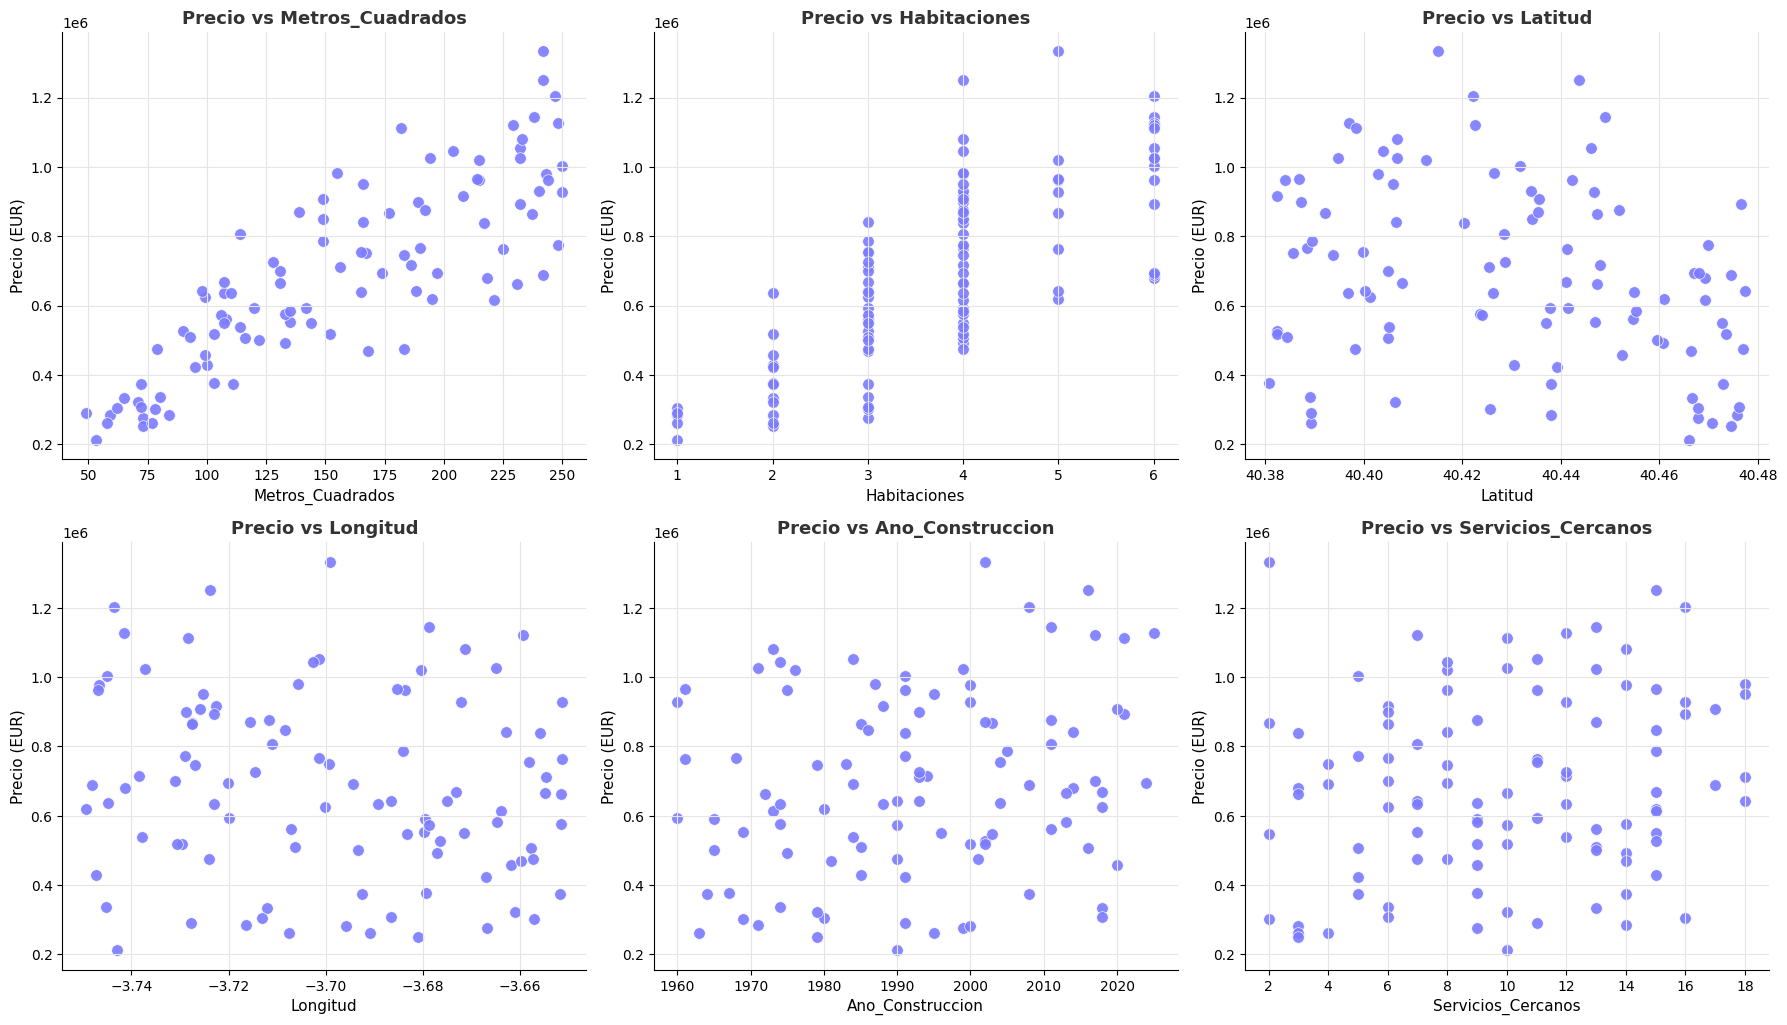

In [211]:
# VISUALIZACIONES: Grid 3x3 - cada variable vs Precio

variables = ["Metros_Cuadrados", "Habitaciones", "Latitud", 
             "Longitud", "Ano_Construccion", "Servicios_Cercanos"]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]
    ax.scatter(
        data_[var],
        data_["Precio_Comercial_EUR"],
        color="#7a7bff",
        edgecolor="white",
        linewidth=0.5,
        s=70,
        alpha=0.9,
    )
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel("Precio (EUR)", fontsize=11)
    ax.set_title(f"Precio vs {var}", fontsize=13, fontweight="bold", color="#333333")
    ax.grid(color="#e5e5e5", linestyle="-", linewidth=0.8)
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Ocultar los 3 subplots sobrantes (solo tenemos 6 variables para un grid de 9)
for j in range(len(variables), 9):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

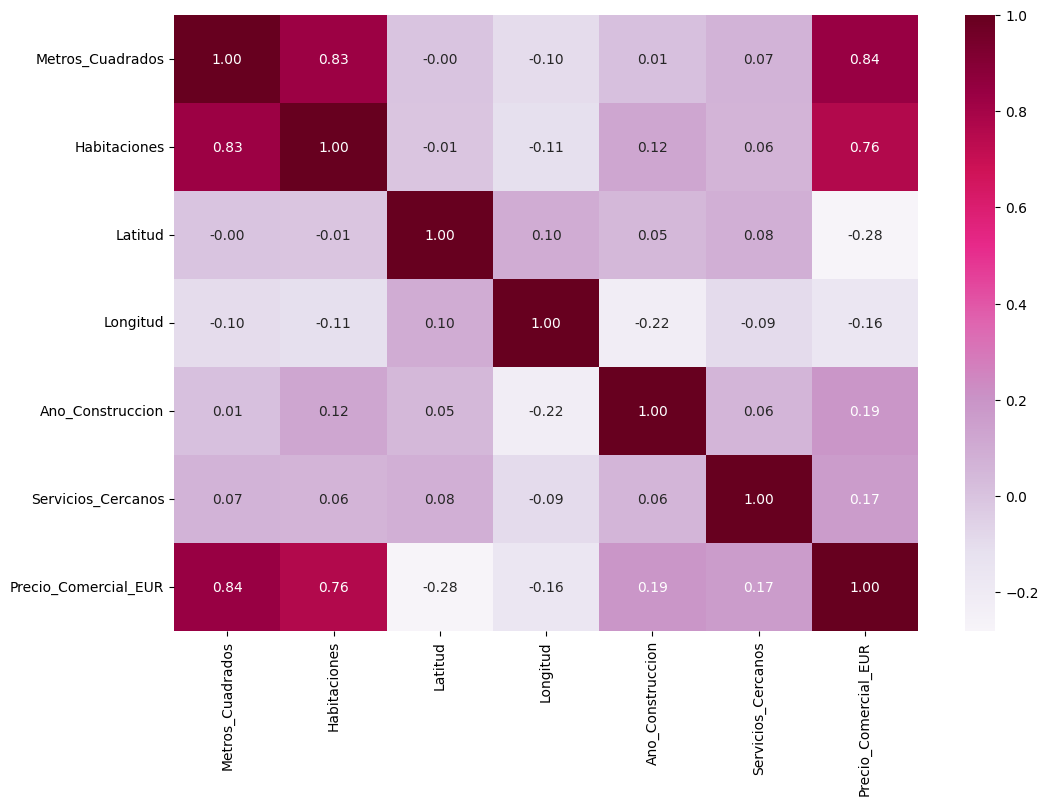

In [212]:
# Revisamos qué correlación existe entre las variables

plt.figure(figsize=(12, 8))
sns.heatmap(data_.corr(numeric_only=True),
            annot=True,
            cmap="PuRd",
            fmt=".2f")

plt.show()

In [213]:
# División train/test (80/20)

data_train, data_test = train_test_split(
    data_, test_size=0.2, random_state=42
)

print(f"Filas en train: {len(data_train)}")
print(f"Filas en test: {len(data_test)}")

Filas en train: 80
Filas en test: 20


In [214]:
from sklearn.preprocessing import StandardScaler

variables_predictoras = ['Metros_Cuadrados', 'Habitaciones', 'Ano_Construccion', 'Servicios_Cercanos', 'Latitud']

# El scaler se "aprende" SOLO con los datos de train, para no filtrar información del test
scaler = StandardScaler()

data_train_scaled = data_train.copy()
data_test_scaled = data_test.copy()

data_train_scaled[variables_predictoras] = scaler.fit_transform(data_train[variables_predictoras])
data_test_scaled[variables_predictoras] = scaler.transform(data_test[variables_predictoras])

In [215]:
# Construcción del modelo

print("CASO 2 Regresión Múltiple sin colinealidad")

modelo_multiple = ols(
    'Precio_Comercial_EUR ~ Metros_Cuadrados + Habitaciones + Ano_Construccion + Servicios_Cercanos + Latitud',
    data=data_train
).fit()

print("\n--- RESUMEN DEL MODELO (Train) ---")
print(modelo_multiple.summary().tables[1])
print("R2 (train):", round(modelo_multiple.rsquared, 4))
print("R2-ajustado (train):", round(modelo_multiple.rsquared_adj, 4))

CASO 2 Regresión Múltiple sin colinealidad

--- RESUMEN DEL MODELO (Train) ---
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           9.988e+07   1.66e+07      6.015      0.000    6.68e+07    1.33e+08
Metros_Cuadrados    3139.6846    373.579      8.404      0.000    2395.312    3884.057
Habitaciones        2.467e+04   1.67e+04      1.478      0.144   -8577.850    5.79e+04
Ano_Construccion    2889.0254    704.813      4.099      0.000    1484.655    4293.396
Servicios_Cercanos  7091.4689   2742.019      2.586      0.012    1627.877    1.26e+04
Latitud            -2.612e+06   4.11e+05     -6.356      0.000   -3.43e+06   -1.79e+06
R2 (train): 0.8411
R2-ajustado (train): 0.8304


- Metros_Cuadrados: cada metro adicional 3.139€ | p(0.05) < 0.000
- Latitud: a medida que aumenta la latitud, el precio de la vivienda baja:  -2.612.000€ | p(0.05) < 0.000
- Habitaciones: cada habitación adicional 29.870€  | p(0.05) < 0.144 * YA NO ES SIGNIFICATIVA  
- Ano_Construccion: cada año nuevo 2.616€          | p(0.05) < 0.000     
- Servicios_Cercanos = cada servicio adional 7.449€ | p(0.05) < 0.003

- R² = estas 4 variables explican el 84 % de la variacion del precio
- R² ajustado --> muy cerca de R²

In [216]:
# Calcular VIF

print("\n--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---")
matriz_x_sin = modelo_multiple.model.exog
for i in range(1, matriz_x_sin.shape[1]):
    vif = variance_inflation_factor(matriz_x_sin, i)
    print("Variable", modelo_multiple.model.exog_names[i], ": VIF =", round(vif, 2))


--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---
Variable Metros_Cuadrados : VIF = 3.43
Variable Habitaciones : VIF = 3.45
Variable Ano_Construccion : VIF = 1.01
Variable Servicios_Cercanos : VIF = 1.0
Variable Latitud : VIF = 1.01


- Todos los valores debajo de 5 --> no hay multicolinealidad

In [217]:
# Calcular el determinante de la matriz de correlación

X_train_vars = data_train[['Metros_Cuadrados', 'Habitaciones', 'Ano_Construccion', 'Servicios_Cercanos', 'Latitud']]
matriz_corre = X_train_vars.corr()

determinante = np.linalg.det(matriz_corre)
print(round(determinante, 4))

if determinante < 0.01:
    print("Existe fuerte evidencia de multicolinealidad")
elif determinante < 0.1:
    print("Existe cierta multicolinealidad")
else:
    print("No se observan problemas importantes de multicolinealidad")

0.2887
No se observan problemas importantes de multicolinealidad


- Por encima de 0.1 --> no hay multicolinealidad

In [218]:
# Predicciones y métricas sobre TEST

y_pred_lineal_test = modelo_multiple.predict(data_test)
y_real_test = data_test["Precio_Comercial_EUR"]

mae = mean_absolute_error(y_real_test, y_pred_lineal_test)
rmse = np.sqrt(mean_squared_error(y_real_test, y_pred_lineal_test))
r2_test = r2_score(y_real_test, y_pred_lineal_test)
mape = np.mean(np.abs((y_real_test - y_pred_lineal_test) / y_real_test)) * 100

print("\n--- RESULTADOS SOBRE TEST (datos no vistos) ---")
print(f"MAE: {mae:,.2f} €")
print(f"RMSE: {rmse:,.2f} €")
print(f"R² (test): {r2_test:.4f}")
print(f"MAPE: {mape:.2f}%")


--- RESULTADOS SOBRE TEST (datos no vistos) ---
MAE: 84,971.74 €
RMSE: 102,925.05 €
R² (test): 0.8480
MAPE: 13.37%



--- RESULTADOS SOBRE TEST (modelo normalizado) ---
MAE: 84,971.74 €
RMSE: 102,925.05 €
R² (test): 0.8480
MAPE: 13.37%

In [219]:
# Cálculo manual de las predicciones usando los coeficientes del modelo

coefs = modelo_multiple.params

data_test = data_test.copy()

data_test["Precio_Predicho_Manual"] = (
    coefs["Intercept"]
    + coefs["Metros_Cuadrados"] * data_test["Metros_Cuadrados"]
    + coefs["Habitaciones"] * data_test["Habitaciones"]
    + coefs["Ano_Construccion"] * data_test["Ano_Construccion"]
    + coefs["Servicios_Cercanos"] * data_test["Servicios_Cercanos"]
    + coefs["Latitud"] * data_test["Latitud"]
)

data_test["Precio_Predicho_Modelo"] = y_pred_lineal_test

data_test["Diferencia"] = data_test["Precio_Comercial_EUR"] - data_test["Precio_Predicho_Modelo"]

data_test[["Metros_Cuadrados", "Habitaciones", "Ano_Construccion",
           "Servicios_Cercanos", "Latitud", "Precio_Comercial_EUR",
           "Precio_Predicho_Manual", "Precio_Predicho_Modelo", "Diferencia"]].head(10)

,Metros_Cuadrados,Habitaciones,Ano_Construccion,Servicios_Cercanos,Latitud,Precio_Comercial_EUR,Precio_Predicho_Manual,Precio_Predicho_Modelo,Diferencia
83,204,4,1974,8,40.40385,1044450,8.527973e+05,8.527973e+05,191652.676357
53,165,3,2004,11,40.39996,754332,8.237876e+05,8.237876e+05,-69455.633027
70,229,6,2017,7,40.42267,1120386,1.048607e+06,1.048607e+06,71779.244182
45,58,1,1995,3,40.38923,260556,3.837987e+05,3.837987e+05,-123242.720737
44,98,3,1993,18,40.40036,641682,6.302451e+05,6.302451e+05,11436.928291
39,78,3,1969,2,40.42572,301696,3.184175e+05,3.184175e+05,-16721.516681
22,238,6,2011,13,40.44899,1143007,1.033338e+06,1.033338e+06,109669.445395
80,131,4,2013,10,40.40783,664321,7.400605e+05,7.400605e+05,-75739.545035
10,243,4,2000,14,40.40290,978501,1.095390e+06,1.095390e+06,-116888.649492
0,208,4,1988,6,40.38250,917281,9.473802e+05,9.473802e+05,-30099.150114


In [220]:
# Media general de las diferencias (residuos), calculada sobre TEST

media_diferencia = data_test["Diferencia"].mean()
media_diferencia_absoluta = data_test["Diferencia"].abs().mean()

print(f"Media de la diferencia (con signo): {media_diferencia:,.2f} €")
print(f"Media de la diferencia absoluta (sin signo): {media_diferencia_absoluta:,.2f} €")

Media de la diferencia (con signo): -17,366.78 €
Media de la diferencia absoluta (sin signo): 84,971.74 €


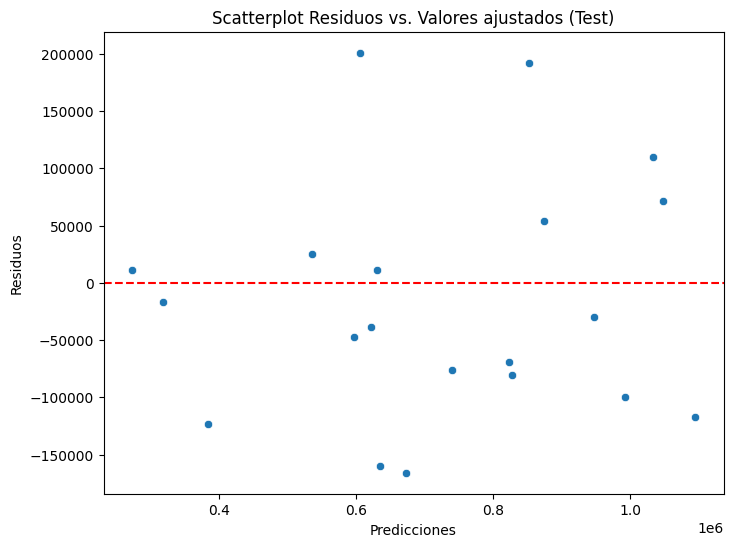

In [221]:
# Gráfico de residuos vs. valores ajustados, calculado sobre TEST

plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_test["Precio_Predicho_Modelo"], y=data_test["Diferencia"])
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
plt.title("Scatterplot Residuos vs. Valores ajustados (Test)")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.show()

- El modelo acierta muy bien el precio de viviendas baratas, pero no para viviendas caras. 

In [222]:
# Normalizamos las variables predictoras
# El scaler se "aprende" SOLO con los datos de train, para no filtrar información del test

variables_predictoras = ['Metros_Cuadrados', 'Habitaciones', 'Ano_Construccion', 'Servicios_Cercanos', 'Latitud']

scaler = StandardScaler()

data_train_scaled = data_train.copy()
data_test_scaled = data_test.copy()

data_train_scaled[variables_predictoras] = scaler.fit_transform(data_train[variables_predictoras])
data_test_scaled[variables_predictoras] = scaler.transform(data_test[variables_predictoras])

In [223]:
# Construcción del modelo normalizado (para comparar importancia relativa de variables)

modelo_multiple_normalizado = ols(
    'Precio_Comercial_EUR ~ Metros_Cuadrados + Habitaciones + Ano_Construccion + Servicios_Cercanos + Latitud',
    data=data_train_scaled
).fit()

print("\n--- RESUMEN DEL MODELO NORMALIZADO (Train) ---")
print(modelo_multiple_normalizado.summary().tables[1])
print("R2 (train):", round(modelo_multiple_normalizado.rsquared, 4))
print("R2-ajustado (train):", round(modelo_multiple_normalizado.rsquared_adj, 4))


--- RESUMEN DEL MODELO NORMALIZADO (Train) ---
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           6.823e+05   1.22e+04     55.990      0.000    6.58e+05    7.07e+05
Metros_Cuadrados    1.896e+05   2.26e+04      8.404      0.000    1.45e+05    2.35e+05
Habitaciones        3.346e+04   2.26e+04      1.478      0.144   -1.16e+04    7.86e+04
Ano_Construccion    5.028e+04   1.23e+04      4.099      0.000    2.58e+04    7.47e+04
Servicios_Cercanos  3.156e+04   1.22e+04      2.586      0.012    7243.596    5.59e+04
Latitud            -7.794e+04   1.23e+04     -6.356      0.000   -1.02e+05   -5.35e+04
R2 (train): 0.8411
R2-ajustado (train): 0.8304


In [224]:
# Importancia relativa de cada variable (coeficientes ya comparables entre sí)

importancia = pd.DataFrame({
    "Variable": modelo_multiple_normalizado.params.index[1:],  # excluye el Intercept
    "Coeficiente_Normalizado": modelo_multiple_normalizado.params.values[1:]
})
importancia["Peso_Absoluto"] = importancia["Coeficiente_Normalizado"].abs()
importancia = importancia.sort_values("Peso_Absoluto", ascending=False)

importancia

,Variable,Coeficiente_Normalizado,Peso_Absoluto
0,Metros_Cuadrados,189586.971966,189586.971966
4,Latitud,-77943.862290,77943.862290
2,Ano_Construccion,50278.120397,50278.120397
1,Habitaciones,33458.296806,33458.296806
3,Servicios_Cercanos,31555.044486,31555.044486


In [225]:
# Confirmamos que el modelo normalizado predice exactamente igual en euros

y_pred_normalizado = modelo_multiple_normalizado.predict(data_test_scaled)
y_real_test = data_test_scaled["Precio_Comercial_EUR"]

mae_norm = mean_absolute_error(y_real_test, y_pred_normalizado)
rmse_norm = np.sqrt(mean_squared_error(y_real_test, y_pred_normalizado))
r2_norm = r2_score(y_real_test, y_pred_normalizado)
mape_norm = np.mean(np.abs((y_real_test - y_pred_normalizado) / y_real_test)) * 100

print("\n--- RESULTADOS SOBRE TEST (modelo normalizado) ---")
print(f"MAE: {mae_norm:,.2f} €")
print(f"RMSE: {rmse_norm:,.2f} €")
print(f"R² (test): {r2_norm:.4f}")
print(f"MAPE: {mape_norm:.2f}%")


--- RESULTADOS SOBRE TEST (modelo normalizado) ---
MAE: 84,971.74 €
RMSE: 102,925.05 €
R² (test): 0.8480
MAPE: 13.37%
